# **AI Bootcamp – Week 9 | Day 2 Lab**

# Image Generation Workflows

## Objectives

In this lab, you will explore advanced image generation workflows using Stable Diffusion. Unlike Day 1, where images were generated only from text prompts, today you will learn how to transform existing images, edit specific regions, guide image generation using structural information, and explore text-to-video generation.

By the end of this lab, you will be able to:

- Generate images using Image-to-Image (img2img)
- Understand how the Strength parameter affects generated images
- Edit images using Inpainting
- Guide image generation with ControlNet
- Explore text-to-video generation
- Improve prompts through systematic experimentation

# Step 1 – Enable GPU

Stable Diffusion models require GPU acceleration for efficient execution.

Before continuing:

1. Click **Runtime**
2. Select **Change runtime type**
3. Choose **T4 GPU**
4. Click **Save**

Run the following code to verify that your GPU is available.

In [1]:
import torch

if torch.cuda.is_available():
    print("GPU Available")
    print(torch.cuda.get_device_name(0))
else:
    print("GPU NOT Available")

GPU Available
Tesla T4


# Step 2 – Install Required Libraries

Today's lab requires several additional libraries.

Run the following cell.



In [2]:
!pip -q install diffusers transformers accelerate safetensors opencv-python-headless

# Step 3 – Import Libraries


Complete the missing imports below.

Hint:

You will need

- torch
- numpy
- PIL
- matplotlib
- load_image
- export_to_video

In [4]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from diffusers.utils import load_image, export_to_video

# Image-to-Image (img2img)

Unlike Day 1, today's generation starts with an existing image.

Instead of creating a completely new image, Stable Diffusion modifies the original while preserving some of its structure.

The amount of change is controlled by the **Strength** parameter.
# Load the Image-to-Image Pipeline


Complete the missing code.

Model name:

runwayml/stable-diffusion-v1-5

In [5]:
from diffusers import StableDiffusionImg2ImgPipeline

pipe_img2img = StableDiffusionImg2ImgPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)

pipe_img2img = pipe_img2img.to("cuda")

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

# Load the Sample Image

Run the following cell to download the sample image.

Feel free to swap in your own by uploading it to Colab and loading it with Image.open().

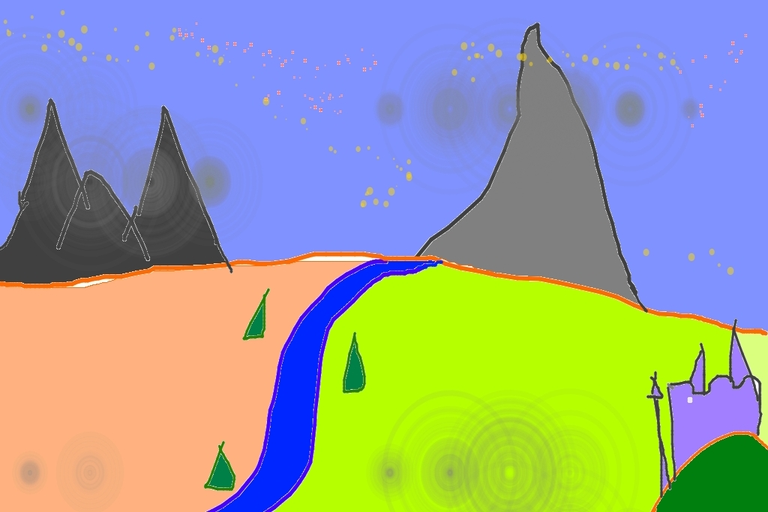

In [6]:
url = "https://raw.githubusercontent.com/CompVis/stable-diffusion/main/assets/stable-samples/img2img/sketch-mountains-input.jpg"
init_image = load_image(url).resize((768, 512))
init_image

 Experiment with the Strength Parameter

The **Strength** parameter determines how much the original image is modified.

Lower values preserve more of the original image.

Higher values generate a more dramatically changed image.


Generate the image using:

- Strength = 0.3
- Strength = 0.6
- Strength = 0.9

  0%|          | 0/15 [00:00<?, ?it/s]

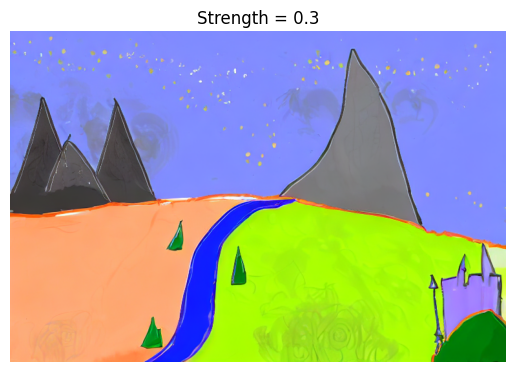

  0%|          | 0/30 [00:00<?, ?it/s]

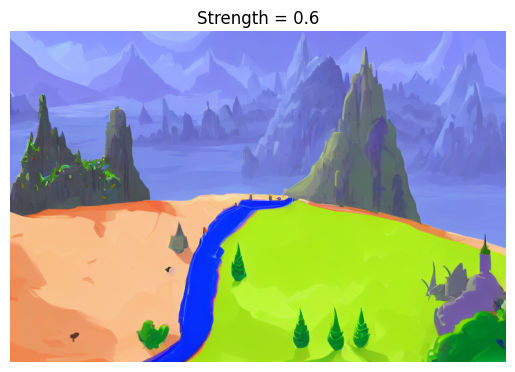

  0%|          | 0/45 [00:00<?, ?it/s]

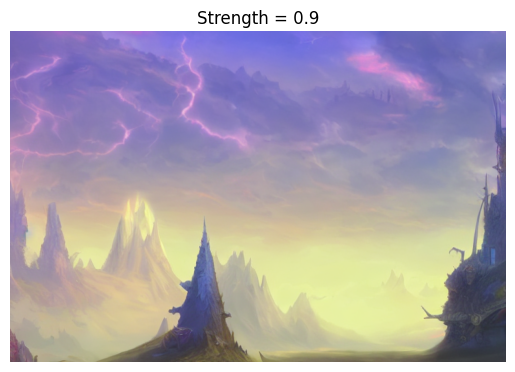

In [7]:
prompt = "a fantasy landscape, trending on artstation"

for strength in [0.3, 0.6, 0.9]:
    image = pipe_img2img(prompt=prompt, image=init_image, strength=strength, guidance_scale=7.5).images[0]
    image.save(f"output_strength_{strength}.png")
    plt.imshow(image)
    plt.title(f"Strength = {strength}")
    plt.axis("off")
    plt.show()

## Reflection

1. Which strength preserved the original image best?

2. Which strength produced the largest transformation?

3. Which value would you choose if the client wanted only small edits?

In [9]:
#strength 0.3 preserve the orginial image more.
# Does the edited region blend naturally with the rest of the image? Mostly yes — lighting and edges usually match well, though sometimes the mask boundary shows a slight seam or mismatch in texture/shadow direction.
# What happens if the prompt is vague vs. very specific? A vague prompt gives more random, varied results each run; a specific prompt gives more consistent, controlled output that closely matches what you described.

#  Inpainting

Instead of changing the whole image, Inpainting edits only the masked region.

The white region of the mask is regenerated.

The black region remains unchanged.

Load the Inpainting Pipeline


Complete the code below.

In [10]:
from diffusers import StableDiffusionInpaintPipeline

pipe_inpaint = StableDiffusionInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-inpainting",
    torch_dtype=torch.float16
)

pipe_inpaint = pipe_inpaint.to("cuda")

model_index.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Load an image and its mask.

The mask is white where you want new content generated, and black where the original should stay untouched.

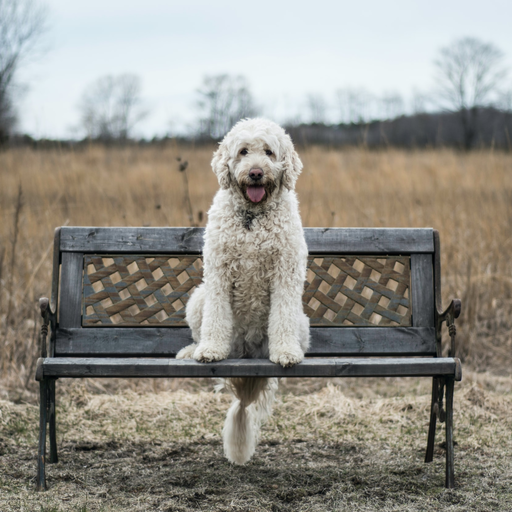

In [13]:
img_url = "https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo.png"
mask_url = "https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo_mask.png"

init_image = load_image(img_url).resize((512, 512))
mask_image = load_image(mask_url).resize((512, 512))

init_image


 Regenerate the masked region.

 **prompt =** "a majestic tiger sitting on a bench"

  0%|          | 0/50 [00:00<?, ?it/s]

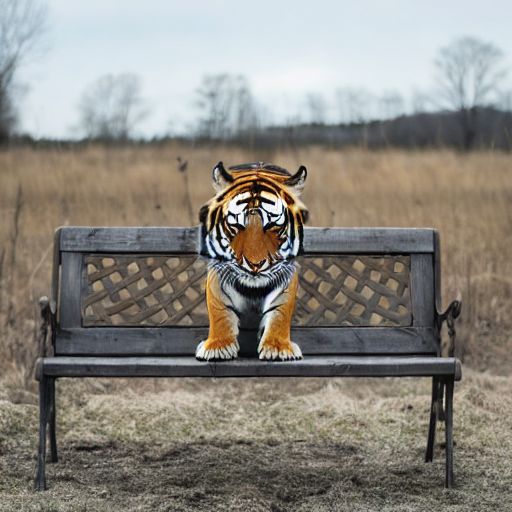

In [14]:
prompt = "a majestic tiger sitting on a bench"
result = pipe_inpaint(prompt=prompt, image=init_image, mask_image=mask_image).images[0]
result

##**Discussion**
    • Does the edited region blend naturally with the rest of the image?
    • What happens if you make the prompt vague vs. very specific?

In [15]:
#yes — the lighting, background field, and bench match well, but the tiger's pose looks stiff and slightly cropped/cut off compared to the dog's natural sitting posture.
#The specific prompt ("majestic tiger sitting on a bench") still produced an odd, front-facing, awkwardly-posed tiger rather than a natural sitting pose — showing that even detailed prompts don't guarantee anatomically correct blending with the masked region's original pose.

 # **ControlNet**

 Install and load ControlNet

In [16]:
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel
import cv2

controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-canny",
    torch_dtype=torch.float16
)

pipe_cn = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet,
    torch_dtype=torch.float16
).to("cuda")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors: reconstructing file:   0%|          |  0.00B / 1.45GB            

diffusion_pytorch_model.safetensors: downloading bytes:           |  0.00B            

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Create a Canny edge map from a reference image

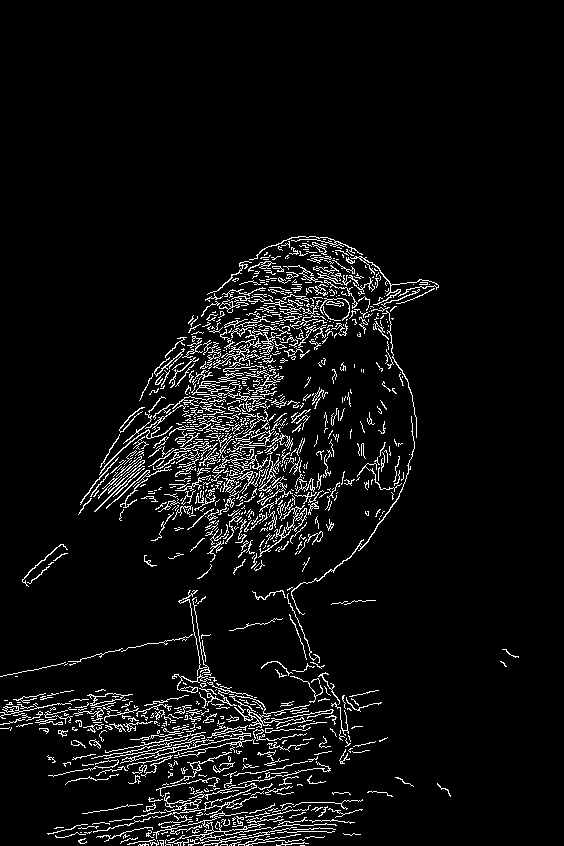

In [17]:
url = "https://huggingface.co/lllyasviel/sd-controlnet-canny/resolve/main/images/bird.png"
ref_image = load_image(url)

image_array = np.array(ref_image)
edges = cv2.Canny(image_array, 100, 200)
edges_image = np.stack([edges, edges, edges], axis=-1)  # convert to 3-channel
canny_image = Image.fromarray(edges_image)
canny_image

Generate guided by the edge map.

prompt = "a colorful parrot, highly detailed, studio lighting"

  0%|          | 0/50 [00:00<?, ?it/s]

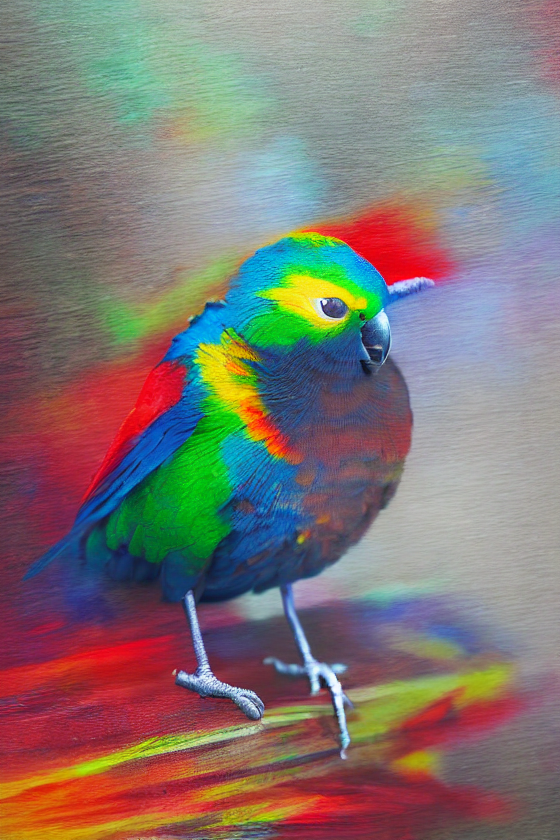

In [18]:
prompt = "a colorful parrot, highly detailed, studio lighting"
result = pipe_cn(prompt=prompt, image=canny_image).images[0]
result

# **Text-to-Video Exploration**

Load a lightweight text-to-video model

In [19]:
from diffusers import DiffusionPipeline, DPMSolverMultistepScheduler

pipe_video = DiffusionPipeline.from_pretrained(
    "damo-vilab/text-to-video-ms-1.7b",
    torch_dtype=torch.float16,
    variant="fp16"
)
pipe_video.scheduler = DPMSolverMultistepScheduler.from_config(pipe_video.scheduler.config)
pipe_video.enable_model_cpu_offload()

model_index.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

The TextToVideoSDPipeline has been deprecated and will not receive bug fixes or feature updates after Diffusers version 0.33.1. 


Generate a short clip

In [20]:
prompt = "a golden retriever running on a beach at sunset"

video_frames = pipe_video(prompt, num_inference_steps=25).frames[0]
video_path = export_to_video(video_frames)
video_path

  0%|          | 0/25 [00:00<?, ?it/s]

'/tmp/tmpjaql7fqo.mp4'

Download the file from the Colab file browser (folder icon on the left) to watch it, or display it inline:

In [21]:
from IPython.display import Video
Video(video_path, embed=True)

Compare against a hosted demo.

Try the same prompt on one public text-to-video demo (e.g. a Hugging Face Space).

Note differences in quality, duration, and consistency.
# **Discussion**
    • How does video generation time compare to a single image?
    • What inconsistencies or artifacts do you notice across frames?

In [22]:
#How does video generation time compare to a single image? Video generation takes noticeably longer than a single image, since the model must generate and denoise multiple frames (here, ~16) instead of just one, while also maintaining temporal consistency between them.

#What inconsistencies or artifacts do you notice across frames? Both clips show typical video-diffusion artifacts — warped or "melting" limbs (especially visible in the hosted demo's front legs/tail), slightly flickering fur texture, and imperfect anatomical consistency compared to a single static image generation.